# EVASPA Evaporative Fraction model

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint

In [3]:
from evaspa.edge import LinearEdge, FlatEdge
from evaspa.ef_model import create_efmodel, EFModel

In [4]:
if os.environ["EVASPA_TEST_DATA_PATH"] is None:
    raise Exception("Variable EVASPA_TEST_DATA_PATH must be set")
if os.environ["MNT_PATH"] is None:
    os.environ["MNT_PATH"] = os.environ["EVASPA_TEST_DATA_PATH"]

### Generate test data 

In [5]:
def setup_data(                                                                                                                                                                                                    
    var_min: float,                                                                                                                                                                                                
    var_max: float,                                                                                                                                                                                                
    dry_c1: float,                                                                                                                                                                                                 
    dry_c0: float,                                                                                                                                                                                                 
    wet_c1: float,                                                                                                                                                                                                 
    wet_c0: float,                                                                                                                                                                                                 
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:                                                                                                                                                                    
    """                                                                                                                                                                                                            
    Generate data for tests                                                                                                                                                                                        
    """
    var = np.array([var_min, var_max])

    def dry_edge(v: float) -> float:
        return dry_c1 * v + dry_c0

    def wet_edge(v: float) -> float:
        return wet_c1 * v + wet_c0

    size = 125
    df = pd.DataFrame(
        data={"var": np.random.uniform(low=var_min, high=var_max, size=size * size)}
    )
    df["lst"] = df.apply(
        lambda x: np.random.uniform(wet_edge(x["var"]), dry_edge(x["var"])), axis=1
    )
    df["ef"] = df.apply(
        lambda x: (dry_edge(x["var"]) - x["lst"])
        / (dry_edge(x["var"]) - wet_edge(x["var"])), 
        axis=1,
    )
    lst = df["lst"].to_numpy().reshape(size, -1)
    var = df["var"].to_numpy().reshape(size, -1)
    ef = df["ef"].to_numpy().reshape(size, -1)

    return var, lst, ef

In [6]:
# Parameters
albedo_min = 0.0
albedo_max = 0.6
dry_c1 = -13.0
dry_c0 = 330.0
wet_c1 = 30
wet_c0 = 300.0
# Generate data
albedo, lst, ef_ref = setup_data(
    albedo_min, albedo_max, dry_c1, dry_c0, wet_c1, wet_c0
 )


In [22]:
def plot(var:np.array,lst:np.array,model: EFModel =None, save:bool=False):
    """
    Plot
    """
    # dimensions
    # gridspec inside gridspec
    fig = plt.figure(constrained_layout=True, figsize=(4, 3))

    ax = plt.gca()

    # plot all points
    ax.scatter(var, lst, s=20, alpha=1, color="moccasin", clip_on=False)


    # plot edges
    if model is not None:
        # edges coordinates
        var_max = np.round(np.ceil(np.nanmax(var) * 10) / 10, decimals=1)
        var_min = np.round(np.floor(np.nanmin(var) * 10) / 10, decimals=1)

        var_arr = np.linspace(var_min,var_max,num=20)
        tw_arr = model.twet(var_arr)
        td_arr = model.tdry(var_arr)
        
        ax.plot(
            var_arr,
            td_arr,
            color="tab:red",
            linewidth=3,
            label="dry edge",
            zorder=1,
        )
        ax.plot(
            var_arr,
            tw_arr,
            color="tab:blue",
            linewidth=3,
            label="wet edge",
            zorder=1,
        )

    # Labels
    ax.set_xlabel("Variable")
    ax.set_ylabel("Land Surface Temperature K")

    # title
    ax.set_title("Evaporative fraction method", fontsize=12)

    # savefig
    if save:
        destfile = "ef.png"
        fig.savefig(destfile)

    plt.show()

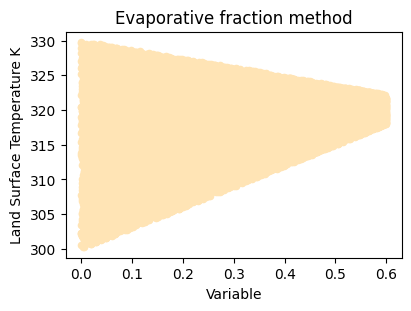

In [8]:
plot(albedo,lst)

## Edge definition

In [9]:
config1 = '{"interval_type":"size","interval_nb":20,"percentile":[98,100],"selection":"max"}'

In [10]:
edge1 = LinearEdge.model_validate_json(config1)

In [11]:
edge1.fit(albedo,lst)

In [12]:
edge1

LinearEdge(percentile=(98, 100),interval_type=size,interval_nb=20,selection=max,coeffs=[-12.83684919 330.02783075])

In [13]:
edge2 = FlatEdge.model_validate_json('{"selection":"max"}')

In [14]:
edge2.fit(albedo,lst)

In [15]:
edge2

FlatEdge(selection=<SelectionFlatMethod.MAX: 'max'>, value=329.80882873433194)

In [16]:
edge3 = FlatEdge.model_validate_json('{"selection":"min"}')
edge3.fit(albedo,lst)
edge3

FlatEdge(selection=<SelectionFlatMethod.MIN: 'min'>, value=300.197908352708)

## EF model definition

In [17]:
config_model1 = {
    "dry_edge":{"type":"LinearEdge",
                "config":{"interval_type":"size","interval_nb":20,"percentile":[98,100],"selection":"median"},
               },
    "wet_edge":{"type":"LinearEdge",
                "config":{"interval_type":"size","interval_nb":20,"percentile":[0,2],"selection":"median"},
         }
}


In [18]:
model1 = create_efmodel(config_model1)

In [19]:
model1.fit(albedo,lst)

In [20]:
model1.compute(albedo,lst)

array([[0.94804014, 0.30291518, 0.7579826 , ..., 0.        , 0.57519376,
        0.31867706],
       [0.36238287, 0.49057441, 0.32789142, ..., 0.95051347, 0.2039988 ,
        0.7026078 ],
       [0.73506732, 0.41857132, 0.23101471, ..., 0.04923177, 0.7673861 ,
        0.27731595],
       ...,
       [0.89653379, 0.24406463, 0.79158229, ..., 0.86944841, 0.6891654 ,
        0.82266487],
       [0.92412923, 0.6203336 , 0.50161117, ..., 0.90523824, 0.99933094,
        0.31697618],
       [0.44468826, 0.86966316, 0.27211741, ..., 0.29188446, 0.36083265,
        0.86939282]])

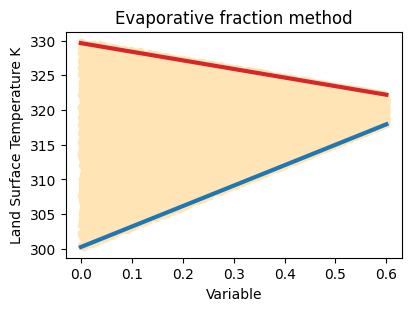

In [23]:
plot(albedo,lst,model=model1)